In [2]:
import sys
!{sys.executable} -m pip install fredapi yfinance alpha_vantage

# Scraping Data

## Macro Data

In [3]:
from fredapi import Fred
import pandas as pd

fred = Fred(api_key='b29fa8db713c7d9498fc161a88fb77ac')

#UNRATE: unemployment rate
#CPIAUCSL: consumer price index (inflaton)
#FEDFUNDS: effective federal funds rate (interest rates)
#GDPC1: Real Gross Domestic Product
#T10Y2Y: Yield Curve (recession indicator)
#TEDRATE: TED Spread (interbank credit risk)
#VIXLS: CBOE (market fear)
#BAMLH0A0HYM2: Bank of America's US High Yield Index (Credit risk)

indexes = ['UNRATE', 'CPIAUCSL', 'FEDFUNDS', 'GDPC1', 'T10Y2Y', 'TEDRATE', 'VIXCLS', 'BAMLH0A0HYM2']

data = {}
for index in indexes:
    data[index] = fred.get_series(index)

df_macro = pd.DataFrame(data)
df_macro.index.name = 'Date'
df_macro = df_macro.loc['2000-01-01':]

In [4]:
df_macro.head()

,UNRATE,CPIAUCSL,FEDFUNDS,GDPC1,T10Y2Y,TEDRATE,VIXCLS,BAMLH0A0HYM2
Date,,,,,,,,
2000-01-01,4.0,169.3,5.45,13878.147,NaN,NaN,NaN,NaN
2000-01-03,NaN,NaN,NaN,NaN,0.20,NaN,24.21,4.68
2000-01-04,NaN,NaN,NaN,NaN,0.19,0.77,27.01,4.81
2000-01-05,NaN,NaN,NaN,NaN,0.24,0.75,26.41,4.77
2000-01-06,NaN,NaN,NaN,NaN,0.22,0.78,25.73,4.82


## Sector Specific

In [5]:
import yfinance as yf

#ticker symbols
# CL=F: crude oil futures
# GC=F: gold futures 
# XLE: energy select sector (correlation with oil)
# XLK: technology select sector
# XLF: financial sector (rate sensistive)
# GSPC: S and P 500 Index
# TNX: 10 year treasuring yield

tickers = ['CL=F', 'GC=F', 'XLE', 'XLK', 'XLF', '^GSPC', '^TNX']
df_sector = yf.download(tickers, start="2000-01-01", interval="1d", auto_adjust=True)['Close']

/Users/lauradiaz/miniforge3/envs/dev_mode_py312/lib/python3.12/site-packages/yfinance/scrapers/history.py:172: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  7 of 7 completed


In [6]:
df_sector.head()

Ticker,CL=F,GC=F,XLE,XLF,XLK,^GSPC,^TNX
Date,,,,,,,
2000-01-03,NaN,NaN,6.699407,11.147916,20.652040,1455.219971,6.548
2000-01-04,NaN,NaN,6.573297,10.660575,19.604296,1399.420044,6.485
2000-01-05,NaN,NaN,6.746695,10.576812,19.313259,1402.109985,6.599
2000-01-06,NaN,NaN,7.006791,11.041307,18.672968,1403.449951,6.549
2000-01-07,NaN,NaN,7.081665,11.224065,18.998943,1441.469971,6.504


## Global Interdependencies

In [7]:
from alpha_vantage.foreignexchange import ForeignExchange 
import time

fe = ForeignExchange(key='DCCXHV23S5TTXJT1', output_format='pandas')

#exchange rates for US dollar against other
currencies = ['EUR', 'KRW', 'CAD']
fx_data = []

for currency in currencies:
    try:
        data, _ = fe.get_currency_exchange_daily(from_symbol='USD', to_symbol=currency)
        
        series = data['4. close'].rename(f'USD_{currency}')
        fx_data.append(series)
        
        # Pause to respect free tier API limits (5 calls per minute)
        time.sleep(3) 
        
    except Exception as e:
        print(f"Error fetching {currency}: {e}")

df_fx = pd.concat(fx_data, axis=1)

In [8]:
df_fx.head()

,USD_EUR,USD_KRW,USD_CAD
date,,,
2026-03-06,0.8607,1481.11,1.3567
2026-03-05,0.8613,1481.08,1.3672
2026-03-04,0.8595,1462.23,1.3641
2026-03-03,0.8609,1480.13,1.3677
2026-03-02,0.8554,1453.59,1.3676


# Data Cleaning + EDA

In [9]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

In [11]:
df_main = df_sector.join(df_macro, how='outer').join(df_fx, how='outer')
df_main.sort_index(inplace=True)

# forward fill bc market uses that monthly or weekly number
# df_main.fillna(method='ffill', inplace=True) (old pandas syntax)
df_main.ffill(inplace=True) # new pandas syntax [f.fillna(method="ffill") -> df.ffill()] & [df.fillna(method="bfill") -> df.bfill()]df_main.dropna(inplace=True)
df_main

,CL=F,GC=F,XLE,XLF,XLK,^GSPC,^TNX,UNRATE,CPIAUCSL,FEDFUNDS,GDPC1,T10Y2Y,TEDRATE,VIXCLS,BAMLH0A0HYM2,USD_EUR,USD_KRW,USD_CAD
Date,,,,,,,,,,,,,,,,,,
2000-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,169.300,5.45,13878.147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-03,NaN,NaN,6.699407,11.147916,20.652040,1455.219971,6.548,4.0,169.300,5.45,13878.147,0.20,NaN,24.21,4.68,NaN,NaN,NaN
2000-01-04,NaN,NaN,6.573297,10.660575,19.604296,1399.420044,6.485,4.0,169.300,5.45,13878.147,0.19,0.77,27.01,4.81,NaN,NaN,NaN
2000-01-05,NaN,NaN,6.746695,10.576812,19.313259,1402.109985,6.599,4.0,169.300,5.45,13878.147,0.24,0.75,26.41,4.77,NaN,NaN,NaN
2000-01-06,NaN,NaN,7.006791,11.041307,18.672968,1403.449951,6.549,4.0,169.300,5.45,13878.147,0.22,0.78,25.73,4.82,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-03,74.559998,5107.399902,56.520000,51.209999,137.500000,6816.629883,4.056,4.4,326.588,3.64,24111.830,0.55,0.09,23.57,3.08,0.8609,1480.13,1.3677
2026-03-04,74.660004,5120.200195,56.189999,51.500000,139.839996,6869.500000,4.080,4.4,326.588,3.64,24111.830,0.55,0.09,21.15,2.97,0.8595,1462.23,1.3641
2026-03-05,81.010002,5065.299805,56.480000,51.230000,140.179993,6830.709961,4.146,4.4,326.588,3.64,24111.830,0.56,0.09,23.75,3.00,0.8613,1481.08,1.3672


In [12]:
df_main.drop(columns=['GDPC1'], inplace=True)
df_main.drop(columns=['TEDRATE'], inplace=True)

In [13]:
# need to make sure PCMCI picks up on actual dependencies, and not just a general growth

df_transform = pd.DataFrame(index=df_main.index)





#1. rates and spreads: these variables are percentages or indices so we care more about the change 
rate_vars = ['UNRATE', 'FEDFUNDS', 'T10Y2Y', 'BAMLH0A0HYM2', 'VIXCLS', 'TEDRATE']

#2. asset prices: grows exponentially and would cause heteroscedasticity so use log 
price_vars = [col for col in df_main.columns if col not in rate_vars]

for col in df_main.columns:
    if col in rate_vars:
        # simple difference
        df_transform[col] = df_main[col].diff()
    else:
        #log of returns (ln(price today / price yesterday))
        df_transform[col] = np.log(df_main[col] / df_main[col].shift(1))

df_transform.dropna(inplace=True)

/Users/lauradiaz/miniforge3/envs/dev_mode_py312/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [14]:
df_transform.head()

,CL=F,GC=F,XLE,XLF,XLK,^GSPC,^TNX,UNRATE,CPIAUCSL,FEDFUNDS,T10Y2Y,VIXCLS,BAMLH0A0HYM2,USD_EUR,USD_KRW,USD_CAD
Date,,,,,,,,,,,,,,,,
2025-10-21,0.005202,-0.059062,-0.002304,-0.001137,0.000520,0.000033,-0.005787,0.0,0.0,0.0,-0.01,-0.36,-0.02,0.003603,0.007110,-0.001069
2025-10-22,0.011692,-0.010649,0.012723,-0.005706,-0.009933,-0.005352,-0.002527,0.0,0.0,0.0,-0.01,0.73,0.04,-0.000812,0.000475,-0.001999
2025-10-23,0.054715,0.019854,0.013238,0.002096,0.012531,0.005810,0.009567,0.0,0.0,0.0,0.01,-1.30,-0.05,-0.000697,0.003277,-0.000286
2025-10-24,-0.004704,-0.001723,-0.010167,0.010790,0.015412,0.007871,0.001502,0.0,0.0,0.0,0.01,-0.93,-0.08,-0.000697,0.001579,0.000429
2025-10-27,-0.003094,-0.028695,0.002382,0.004134,0.018293,0.012215,0.000000,0.0,0.0,0.0,-0.01,-0.58,-0.08,-0.001746,-0.006604,-0.000357


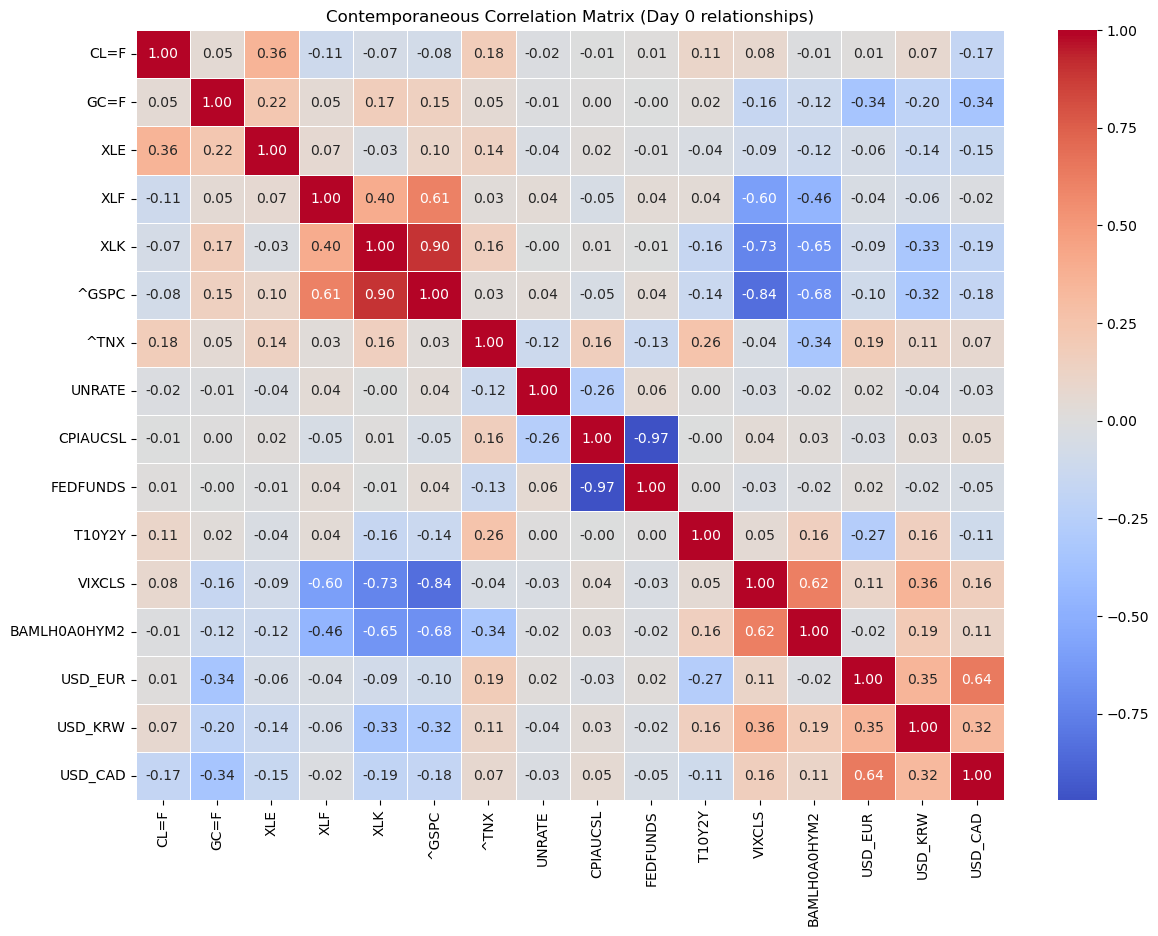

In [15]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_transform.corr(), 
    annot=True,       # Show the numbers
    cmap='coolwarm',  # Blue (Neg) to Red (Pos)
    center=0,         # Set 0 as the middle (white)
    fmt=".2f",        # 2 decimal places
    linewidths=0.5
)
plt.title("Contemporaneous Correlation Matrix (Day 0 relationships)")
plt.show()

# Analysis

In [16]:
# Install Tigramite and dependencies
!pip install Cython
!pip install tigramite
!pip install pandas numpy matplotlib seaborn
!pip install tigramite matplotlib pandas numpy

In [17]:
import sys

# 1. Install specifically for the active kernel
%pip install tigramite

# 2. Add the current environment's path to sys.path manually (emergency bypass)
if sys.prefix not in sys.path:
    sys.path.append(f"{sys.prefix}/lib/python{sys.version_info.major}.{sys.version_info.minor}/site-packages")

# 3. Test the import immediately
try:
    import tigramite
    print("Success! Tigramite is now accessible.")
except ImportError:
    print("Still failing. See the 'Nuclear Option' below.")

Note: you may need to restart the kernel to use updated packages.
Success! Tigramite is now accessible.


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tigramite
from tigramite import data_processing as dp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr # Correct import for v5.0+
from tigramite import plotting as tp
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

## Time Lag Optimization (Elbow Analysis)

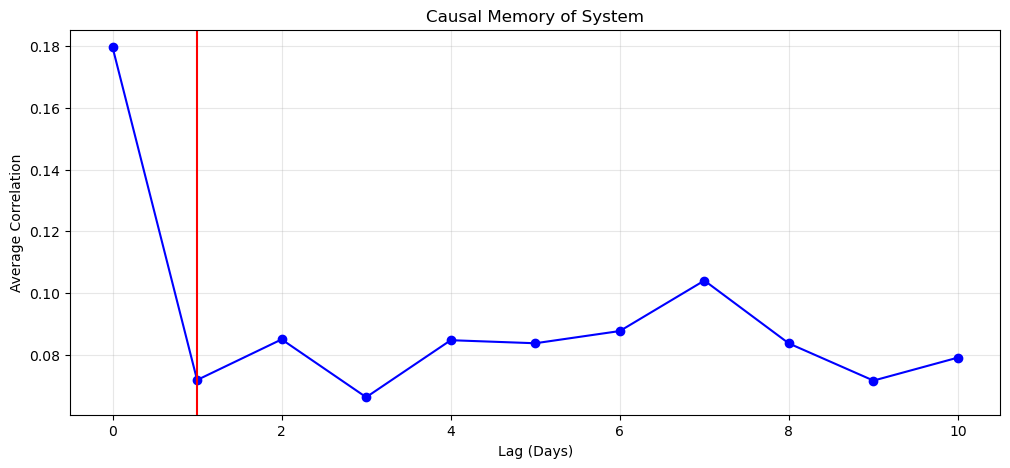

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from tigramite import data_processing as dp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite import plotting as tp

vals = df_transform.values
var_names = df_transform.columns.tolist()

# tigramite dataframe, mapping data to time indices for tau optimization later
dataframe = dp.DataFrame(vals, datatime=np.arange(len(vals)), var_names=var_names)

parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=0)

data_source = df_transform
vals = StandardScaler().fit_transform(data_source.values)
var_names = df_transform.columns.tolist()
T_num = len(vals)

dataframe = dp.DataFrame(vals, datatime=np.arange(T_num), var_names=var_names)
#initilize PCMCI
parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=0)

#tau optimization up to tau=10
tau_results = pcmci.get_lagged_dependencies(tau_max=10, val_only=False)
val_matrix = tau_results['val_matrix']

#avg corrlation for each tau without self dependencies
avg_decays = []
n_vars = val_matrix.shape[0]
for tau in range(11):
    lag_matrix = np.abs(val_matrix[:, :, tau])
    np.fill_diagonal(lag_matrix, 0)
    avg_decays.append(np.sum(lag_matrix) / (n_vars * (n_vars - 1)))


plt.figure(figsize=(12, 5))
plt.title('Causal Memory of System')
plt.plot(range(11), avg_decays, marker='o', color='blue')
plt.xlabel('Lag (Days)')
plt.ylabel('Average Correlation')
plt.axvline(x=1, color='red')
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
optimal_tau = 3

## Optimizing Alpha

In [21]:
# optimizing alpha
alphas = [0.001, 0.01, 0.05, 0.1]
best_bic = float('inf')
best_alpha = None
results_dict = {}

for alpha in alphas:
    # RUN SPECIALIZED MODEL
    # tau_min=1 removes instant noise
    results = pcmci.run_pcmci(tau_min=1, tau_max=optimal_tau, pc_alpha=alpha)
    
    # calc BIC (Bayesian Information Criterion)
    graph = results['graph']
    n_edges = np.count_nonzero(graph != "")
    strength_sum = np.sum(np.abs(results['val_matrix'][graph != ""]))
    
    T_eff = T_num - optimal_tau
    
    # BIC: Penalty for Edges - Reward for Fit
    bic = (n_edges * np.log(T_eff)) - (2 * strength_sum * T_eff)
    
    results_dict[alpha] = results
    
    print(f"Alpha: {alpha:<5} | Edges: {n_edges:<3} | BIC: {bic:.0f}")
    
    if bic < best_bic:
        best_bic = bic
        best_alpha = alpha

print(f"Specialized Alpha: {best_alpha} (Lowest BIC)")

Alpha: 0.001 | Edges: 36  | BIC: -1590
Alpha: 0.01  | Edges: 35  | BIC: -1559
Alpha: 0.05  | Edges: 38  | BIC: -1750
Alpha: 0.1   | Edges: 39  | BIC: -1807
Specialized Alpha: 0.1 (Lowest BIC)


## Visualizing Causal Graphs

In [22]:


split_idx = int(len(vals) * 0.8)
train_vals = vals[:split_idx]
test_vals = vals[split_idx:]

# splitting training and testing based on time series data
train_df = dp.DataFrame(train_vals, datatime=np.arange(len(train_vals)), var_names = var_names)
test_df = dp.DataFrame(test_vals, datatime=np.arange(len(test_vals)), var_names = var_names)

parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=train_df, cond_ind_test=parcorr, verbosity=0)

baseline = pcmci.run_pcmci(tau_min=1, tau_max=5, pc_alpha=0.05)
specialized = pcmci.run_pcmci(tau_min=1, tau_max=2, pc_alpha=0.1)

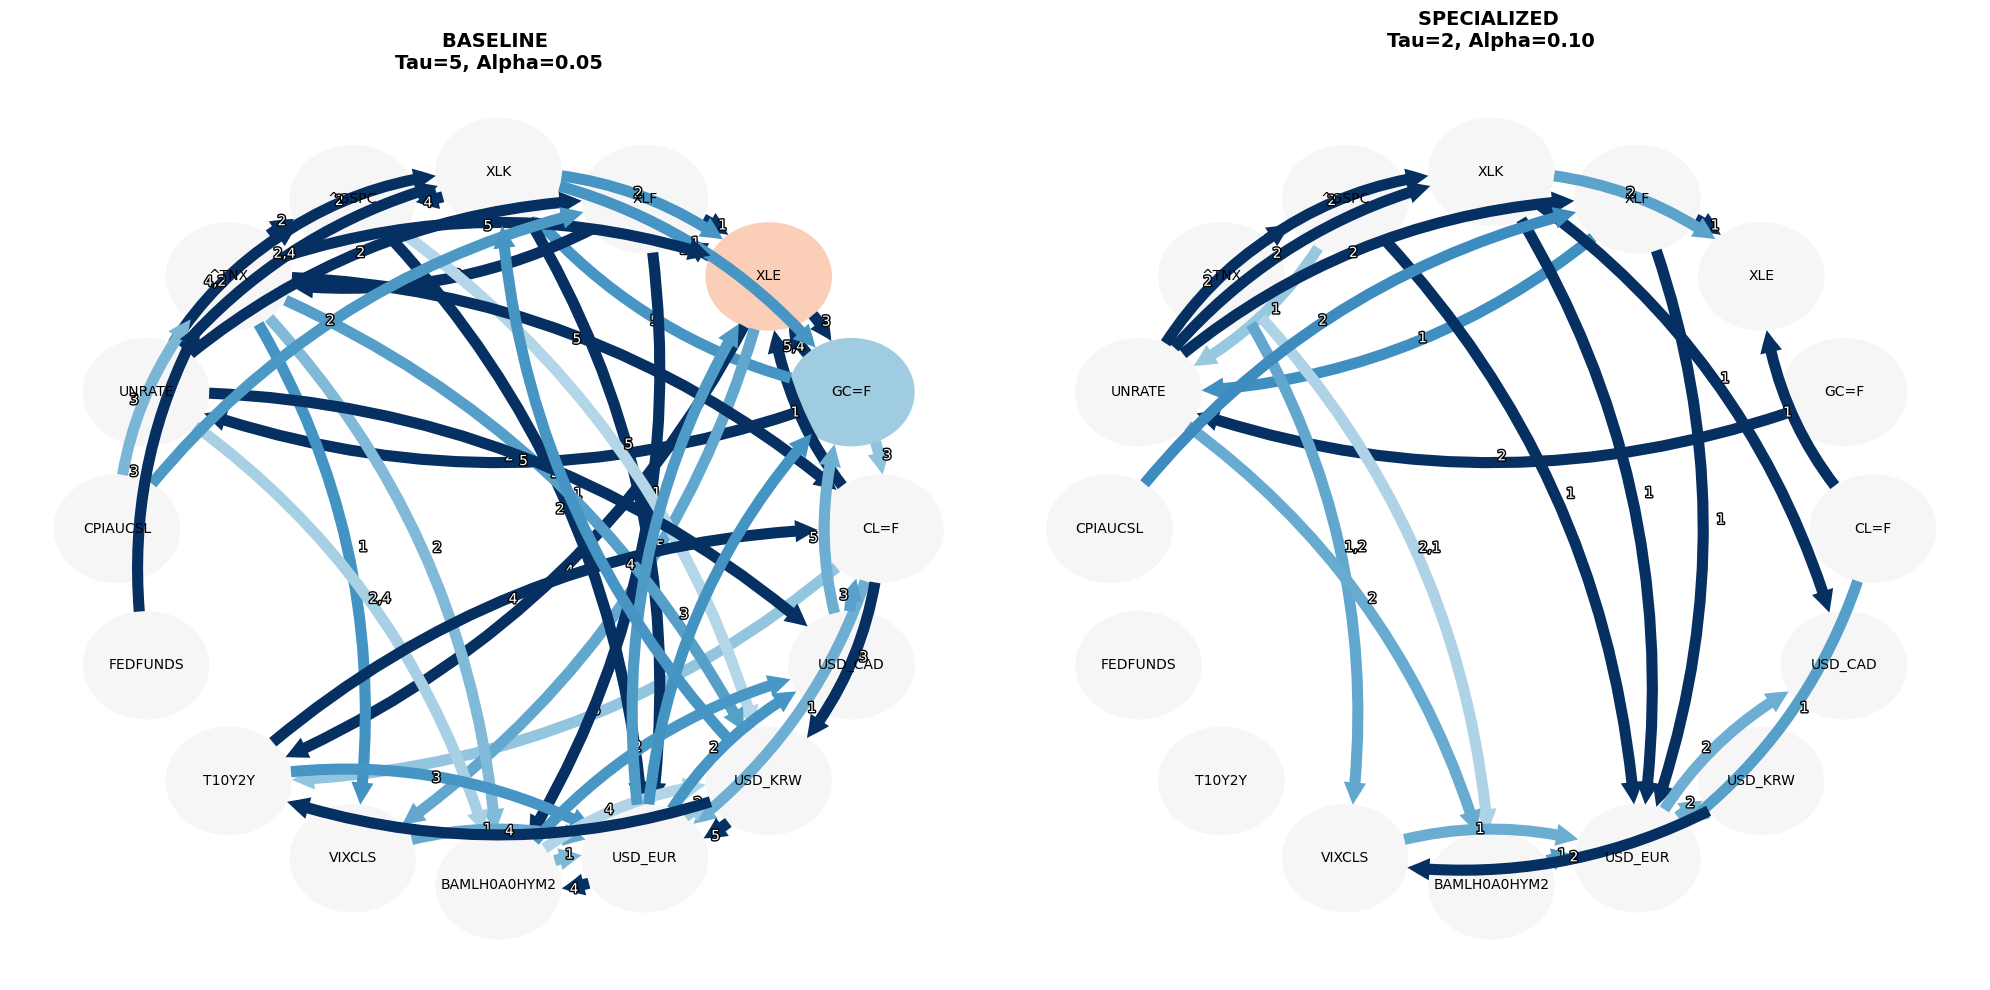

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# plot baseline
tp.plot_graph(
    val_matrix=baseline['val_matrix'],
    graph=baseline['graph'],
    var_names=var_names,
    vmin_edges=0.05,
    show_colorbar=False,
    label_fontsize=10,
    fig_ax=(fig, axes[0]) 
)
axes[0].set_title(f"BASELINE \nTau=5, Alpha=0.05", fontsize=14, fontweight='bold')

# Plot Specialized
tp.plot_graph(
    val_matrix=specialized['val_matrix'],
    graph=specialized['graph'],
    var_names=var_names,
    vmin_edges=0.05,
    show_colorbar=False,
    label_fontsize=10,
    fig_ax=(fig, axes[1])
)
axes[1].set_title(f"SPECIALIZED \nTau=2, Alpha=0.10\n", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


# Re-graping Knowledge Graphs

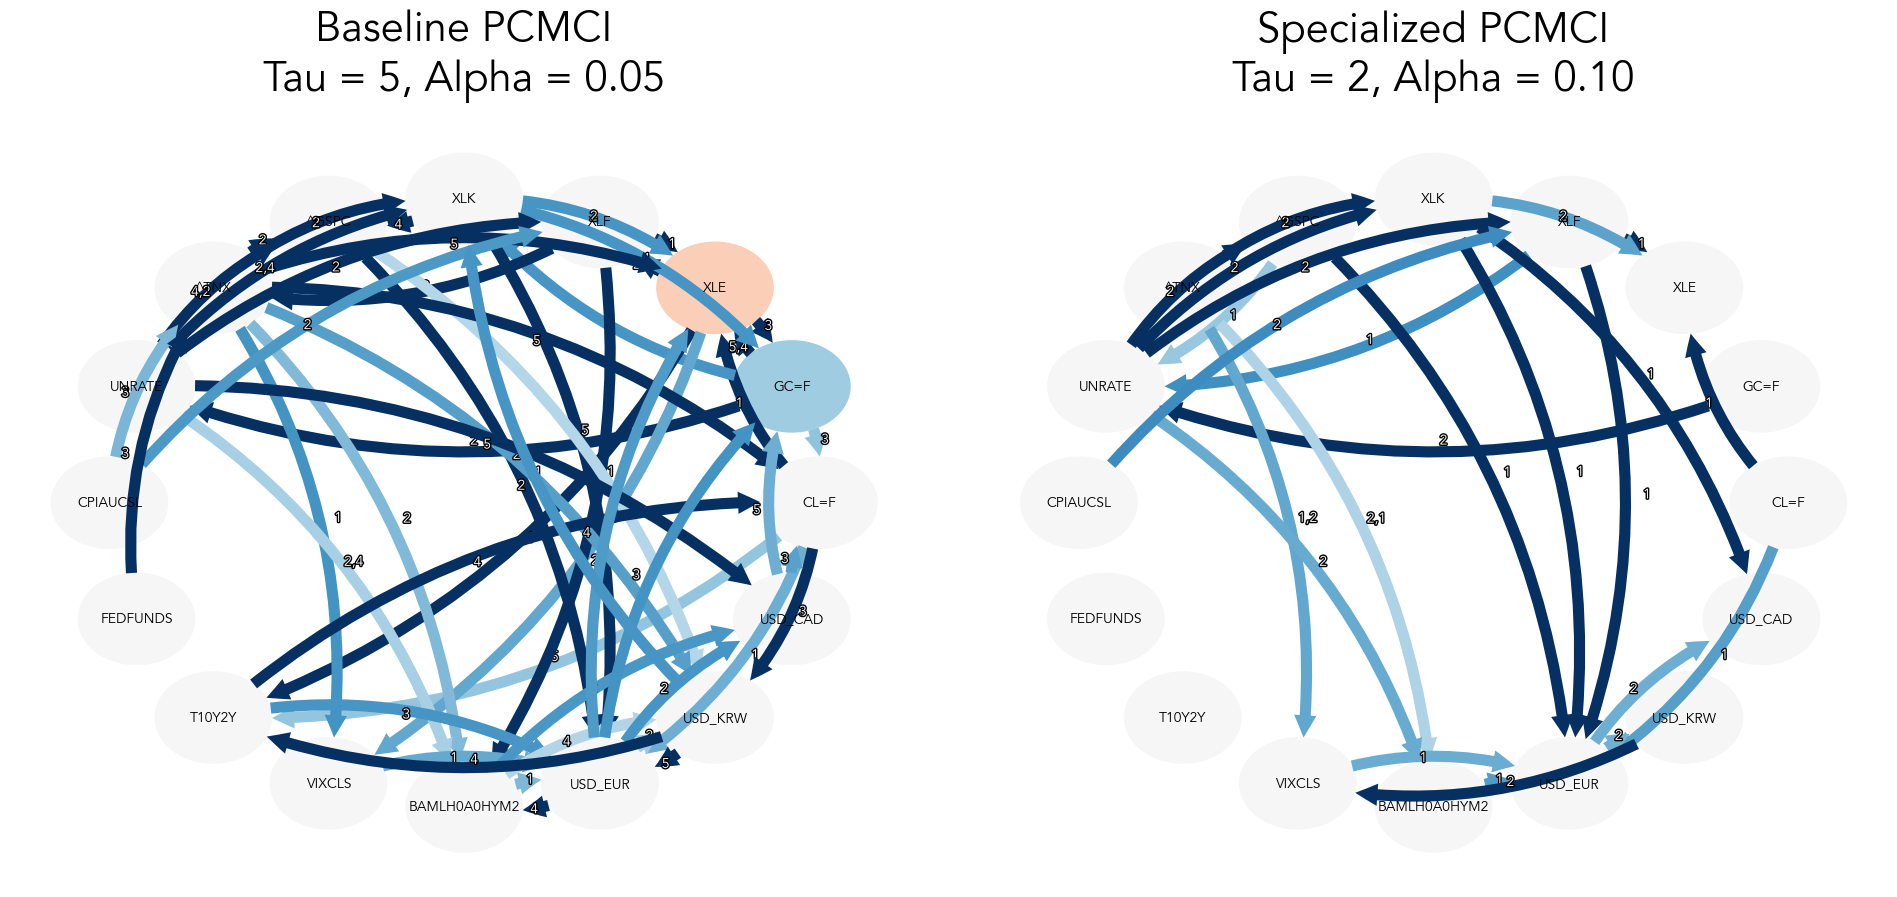

In [30]:
# Match previous poster graph styling
plt.rcParams.update({
    "font.family": "Avenir",      # or "DejaVu Sans" / your chosen fallback
    "font.size": 22,
    "axes.titlesize": 30,
    "axes.labelsize": 26,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "axes.linewidth": 1.2
})

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Plot baseline
tp.plot_graph(
    val_matrix=baseline['val_matrix'],
    graph=baseline['graph'],
    var_names=var_names,
    vmin_edges=0.05,
    show_colorbar=False,
    label_fontsize=18,
    fig_ax=(fig, axes[0])
)
axes[0].set_title(
    "Baseline PCMCI\nTau = 5, Alpha = 0.05",
    pad=20,
    fontweight="bold",
    color="black"
)

# Plot specialized
tp.plot_graph(
    val_matrix=specialized['val_matrix'],
    graph=specialized['graph'],
    var_names=var_names,
    vmin_edges=0.05,
    show_colorbar=False,
    label_fontsize=18,
    fig_ax=(fig, axes[1])
)
axes[1].set_title(
    "Specialized PCMCI\nTau = 2, Alpha = 0.10",
    pad=20,
    fontweight="bold",
    color="black"
)


plt.tight_layout(pad=2)

fig.savefig("poster/knowledge_graphs_comparison.pdf", bbox_inches="tight")

plt.show()